## Classification Model for Loan Default (AMEX Dataset)

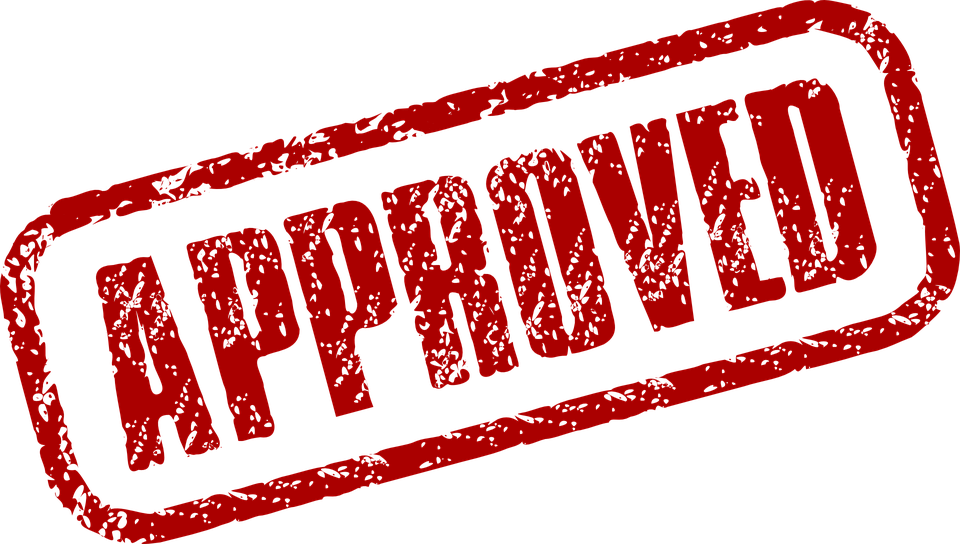

**The what** : We are all familier that banks provide loans to individuals, the individual gets financial help he needs while the banks get interest. The individual repays the loan + intrest and story ends when the full loan is repaid. Their is one critical **if** here, **what if** the loan is not repaid. And that is why we have this dataset.

**The why** : Not being able to repay the loan, be it Unintentional or Intentional has ramifications to both the individual and the bank. The individual suffers as the credit score gets hit, which is a fancy way of saying he will not get any credit ( student loans / car loans etc) and rental accomodation etc. The bank suffers as well as there are additional costs and challenges involved, the loan needs to be restructured etc. It may end up as an NPA to the bank (Non-performing Asset) which hurts the bank and its stakeholders.



**The how** : We are going to stucture this analysis in the below 
* Extract the data & general information
* Visualize the data and outliers
* Data transformation
* Data analysis and Visualization
* Data Cleaning
* Conclusion

<h1>Exploratory Data Analysis</h1>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import pandas as pd
# Sometimes the scientific numbers get on my nerves @#$#$#%&e07 
pd.set_option('display.float_format', lambda x: '%.3f' % x)

import numpy as np
import plotly
from plotly import tools


df = pd.read_csv("../input/amex-competition/dataset/train.csv")
df.head()

In [ ]:
df.describe()

<h3>Few - Things to note</h3>

* First of all Nine children :)
* Second yearly income of 140 Million , holy cow!! sus
* Number of days employed 365252 that is nearly 1000 years 
* Credit limit of 31 Million, seems this should be for 140M guy(or gal )

In [ ]:
df.info()

Hmm lots of columns, Although column names seems to be self explanatory, a formal description is in order 

<table border="1" align="left">
	<tbody>
		<tr>
			<td>
			<p><strong>Column name</strong></p>
			</td>
			<td>
			<p><strong>Description</strong></p>
			</td>
		</tr>
		<tr>
			<td>customer_id</td>
			<td>Represents the unique identification of a customer</td>
		</tr>
		<tr>
			<td>name</td>
			<td>Represents the name of a customer</td>
		</tr>
		<tr>
			<td>age</td>
			<td>Represents the age of a customer ( in years )&nbsp;</td>
		</tr>
		<tr>
			<td>gender</td>
			<td>Represents the gender of a customer( F means Female and M means Male &nbsp;)</td>
		</tr>
		<tr>
			<td>owns_car</td>
			<td>Represents whether a customer owns a car ( Y means Yes and N means No &nbsp;)&nbsp;</td>
		</tr>
		<tr>
			<td>owns_house</td>
			<td>Represents whether a customer owns a house ( Y means Yes and N means No &nbsp;)</td>
		</tr>
		<tr>
			<td>no_of_children</td>
			<td>Represents the number of children of a customer&nbsp;</td>
		</tr>
		<tr>
			<td>net_yearly_income</td>
			<td>Represents the net yearly income of a customer ( in USD )&nbsp;</td>
		</tr>
		<tr>
			<td>no_of_days_employed</td>
			<td>Represents the no of days employed</td>
		</tr>
		<tr>
			<td>occupation_type</td>
			<td>Represents the occupation type of a customer ( IT staff, Managers, Accountants, Cooking staff, etc )</td>
		</tr>
		<tr>
			<td>total_family_members</td>
			<td>Represents the number of family members of a customer</td>
		</tr>
		<tr>
			<td>migrant_worker</td>
			<td>Represents whether a customer is a migrant worker( 1 means Yes and 0 means No &nbsp;)&nbsp;</td>
		</tr>
		<tr>
			<td>yearly_debt_payments</td>
			<td>Represents the yearly debt payments of a customer &nbsp;( in USD )</td>
		</tr>
		<tr>
			<td>credit_limit</td>
			<td>Represents the credit limit of a customer &nbsp;( in USD )&nbsp;</td>
		</tr>
		<tr>
			<td>credit_limit_used(%)</td>
			<td>Represents the percentage of credit limit used by a customer</td>
		</tr>
		<tr>
			<td>credit_score</td>
			<td>Represents the credit score of a customer</td>
		</tr>
		<tr>
			<td>prev_defaults</td>
			<td>Represents the number of previous defaults</td>
		</tr>
		<tr>
			<td>default_in_last_6months</td>
			<td>Represents whether a customer has defaulted in the last 6 months ( 1 means Yes and 0 means No &nbsp;)&nbsp;</td>
		</tr>
		<tr>
			<td>credit_card_default</td>
			<td>Represents whether there will be credit card default &nbsp;( 1 means Yes and 0 means No &nbsp;)&nbsp;</td>
		</tr>
	</tbody>
</table>

Lets first identify the nulls right away, Here we would see what can be done with these columns :
* Simplest way is to remove ( but wheres the fun in that !!)
* One way is to impute them ( Simpleimputer - Mean - Median - most frequent etc )  
* if these are critical columns ( that you would identify based on feature importance later we may use more statistical methods )

More details [towardsdatascience](https://towardsdatascience.com/6-different-ways-to-compensate-for-missing-values-data-imputation-with-examples-6022d9ca0779) & [MachinelearningMastery](https://machinelearningmastery.com/statistical-imputation-for-missing-values-in-machine-learning/)

As we are just doing EDA here, lets just continue

In [ ]:
print('Number of nulls per column')
df[df.columns[df.isnull().any()]].isnull().sum()

In [ ]:
print('Percentage of nulls per column')
df[df.columns[df.isnull().any()]].isnull().sum() * 100 / df.shape[0]

<h4>Check String Values</h4>
Numbers are always easy to handle, its the text that causes more problems, it would always be a good idea to go over those and these bad boys identify themselves before they can cause damange.

Below code would quickly run over string columns and show us the details of those columns 

In [ ]:
print(f'Total dataframe values {df.size} with unique values as below :')
for c in df.columns.to_list():
    if df[c].dtype == object and isinstance(df.iloc[0][c], str):
        print(f'{c} : {df[c].nunique()} : Sample : {df[c].unique()[:3]}')

See that XNA, who would have though of that


Also its alos a good idea to get to know about the balance of the dataset, generally the better balance we have it the better for algorithms else the bais is clearly seen in predictions, if not catered for early on.

Also I am not an expert in plotly, you can find more information [Kaggle page](https://www.kaggle.com/saurav9786/plotly-tutorial-for-everyone)

In [ ]:
import plotly.express as px
s = df['credit_card_default']
fig = px.pie(s, values=s.value_counts().values, names=s.value_counts().index)
fig.update_traces(hoverinfo='label', textinfo='value+percent')
fig.show()

Phew!! you can look at the imbalance ~3 to 41, <br>
Well atleast one good thing, only ~4 in 45 people default as per the statistic

In [ ]:
dfp = df.groupby(['gender','credit_card_default']).size().reset_index(name='gender_default')
fig = px.bar(dfp,
             x="gender",
             y="gender_default",
             color='credit_card_default',
             barmode='stack')
fig.show()

Where there is no gender inequality here, **Go Ladies !!!!** <br>
Seems males are only half of the total polutation

In [ ]:
print('Percentage of defaults for each gender')
table = pd.pivot_table(df, values='customer_id', index=['gender'],
                    columns=['credit_card_default'], aggfunc="count",margins=True)
table2 = table.div( table.iloc[:,-1], axis=0 )
table2

Males being less in number still have higher default percentage **Ouuch!!!**

In [ ]:
df[['occupation_type', 'credit_card_default']].groupby(['occupation_type']).agg(['count'])

In [ ]:
print('Percentage of defaults for each occupation')
table = pd.pivot_table(df, values='gender', index=['occupation_type'],
                    columns=['credit_card_default'], aggfunc="count",margins=True)

table2 = table.div( table.iloc[:,-1], axis=0 )
table2


Lower skills have a higher default rates, converting these into ordinal data would be a good idea , but then where would unkowns fit. for now we can use the universl dummies and get along with it
IT Staff has the lowest percentage defaults. 

In [ ]:
import plotly.express as px
fig = px.histogram(df, x="credit_limit_used(%)",  color="credit_card_default", marginal="rug",
                   hover_data=df.columns)
fig.show()

Well, plotly is amazing but heavy, I see the page lagging now, I am going to continue with seaborn, but you get the idea now.

Also do you see defaults mostly seem to happen when credit limit exceeds 70% 

**So make sure you do not reach that stage** , if you do , remember its a warning sign

In [ ]:
import seaborn as sb
sb.histplot(data=df, x='credit_score', hue="credit_card_default", multiple="stack")

And also make sure that you improve your **credit score beyond 700**

Bot the above graphs have made me curious, seems default is strongly a function of score and credit limit used 

In [ ]:
sb.scatterplot(data=df, x="credit_score", y="credit_limit_used(%)", hue="credit_card_default")

**Almost Seperable !!!!** this is an amazing discovery right there my man!!!

In [ ]:
    
sb.histplot(data=df, x='prev_defaults', hue="credit_card_default", multiple="stack")

In [ ]:
sb.histplot(data=df, x='default_in_last_6months', hue="credit_card_default", multiple="stack")

Seems once you default, you are very likely to **default again !!!!**

In [ ]:
df['customer_id'].is_unique

In [ ]:
df[(df['credit_limit_used(%)']>70) & (df['credit_score']<700) & (df['credit_score']>150)]['credit_card_default'].value_counts()

Hmmm !!! all the defaults are concentrated in this region 

In [ ]:
#Feature engineering the new column - although i thimk logistic regression would have taken care of this 
def f(row):
    if (row['credit_limit_used(%)'] >70) & (row['credit_score']<700):
        val = 1
    else:
        val = 0
    return val

df['c_defaultchance'] = df.apply(f, axis=1) 


I added another featuere based on the above analysis that defaults are mostly when credit_score < 700 and credit limit used > 70

In [ ]:
df.info()

Created a new feature to store this **knowledge**

In [ ]:
#Simple Regression clasifier
df2 = df.drop(['customer_id','name'], axis = 1)
df2['gender'].replace('F',1, inplace=True)
df2['gender'].replace('M',0, inplace=True)
df2['gender'].replace('XNA',0, inplace=True)

df2['owns_car'].replace(['Y','N'],[1,0],inplace=True)
df2['owns_house'].replace(['Y','N'],[1,0],inplace=True)

for i in df2.columns[df2.isnull().any(axis=0)]:     #---Applying Only on variables with NaN values
    df2[i].fillna(df2[i].mean(),inplace=True)

In [ ]:
#df2 = df2.drop(df2[df2.gender == 'XNA'].index)
#df2 = df2.drop(df2[df2.no_of_days_employed > 365000].index)

df2.loc[df['no_of_days_employed'] > 365000, 'no_of_days_employed'] = 2454.371
df2.loc[df['net_yearly_income'] > 1009012, 'net_yearly_income'] = 1009012.371
df2.loc[df['credit_limit'] > 259012, 'credit_limit'] = 259012.371

df2['credit_score'] = 1000 - df2['credit_score']

df2["gender"] = pd.to_numeric(df2["gender"])

In [ ]:
#https://towardsdatascience.com/beware-of-the-dummy-variable-trap-in-pandas-727e8e6b8bde
df3 = pd.get_dummies(df2, drop_first=True)

In [ ]:
ax1 = df2.plot.scatter(x='no_of_children',
                      y='no_of_days_employed',
                      c='credit_card_default',
                       colormap='viridis')

In [ ]:
#dataplot = sb.heatmap(df3.corr(), cmap="YlGnBu", annot=True)
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20,20))         # Sample figsize in inches


from matplotlib import cm
initial_cmap = cm.get_cmap('gray')
reversed_cmap=initial_cmap.reversed()

sns.heatmap(df3.corr(), annot=True, linewidths=.5, ax=ax,cmap=reversed_cmap)


This is my favorite plot, many things you can tell from this 
* Laborers and Drivers are mostly males 
* Mostly males owns cars
* Credit limit & yearly debt payments is highly corelated with Yearly income 
* number of family members and no of children is highly corelated 

And most importantly , credi tdefault depends on below columns numbers :
 14  credit_limit_used(%)     
 15  credit_score             
 16  prev_defaults           
 17  default_in_last_6months  
 19  c_defaultchance  

In [ ]:
#stratified sampling by target variable
df_sample = df.groupby('credit_card_default', group_keys=False).apply(lambda x: x.sample(1000))

g=sns.pairplot(df_sample, hue="credit_card_default",plot_kws={'alpha':0.6})
g.fig.set_size_inches(30,30)


Again loads of information from here , but the important information that : 
* credit_limit_used
* credit score

<h3>Modelling<h3/>

In [ ]:
import sklearn as sk
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot

In [ ]:
#https://stackabuse.com/classification-in-python-with-scikit-learn-and-pandas/
y = df3.credit_card_default
X = df3.drop(['credit_card_default'], axis = 1)

model = LogisticRegression(random_state=0, solver='liblinear', class_weight='balanced').fit(X, y)

y_pred=model.predict(X)

round(model.score(X,y), 4)

# get importance
name  = model.coef_[0]
roll_no = X.columns.to_list()
zipper = zip(name, roll_no)

res = sorted(zipper, key = lambda x: x[0],reverse=True)

for i, (name, age) in enumerate(res):
    print(i, round(name,3), age)

In [ ]:
from sklearn import metrics
print('Final Score : ' + str(100*(metrics.f1_score(y, y_pred, average= "macro" ))))

In [ ]:
#from sklearn.datasets import load_breast_cancer
#X, y = data = load_breast_cancer(return_X_y=True)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=8675309)

In [ ]:
# Compare Algorithms
import pandas
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import fbeta_score, make_scorer
from sklearn.metrics import f1_score
scoring = make_scorer(f1_score, average='macro')



# load dataset
#url = "../input/testdiabetescsv/pima-indians-diabetes.data.csv"
#names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
#dataframe = pandas.read_csv(url, names=names)
#array = dataframe.values
#X = array[:,0:8]
#Y = array[:,8]
# prepare configuration for cross validation test harness
seed = 7
# prepare models
models = []
models.append(('LR', LogisticRegression(solver='liblinear',class_weight='balanced', max_iter=1000))) # Bug : https://stackoverflow.com/questions/65682019/attributeerror-str-object-has-no-attribute-decode-in-fitting-logistic-regre
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
#models.append(('SVM', SVC()))
models.append(('RF', RandomForestClassifier(n_estimators=100, max_depth=3, random_state=0,class_weight='balanced')))
models.append(('XGB', XGBClassifier(eval_metric='mlogloss',use_label_encoder=False)))
models.append(('ADA',AdaBoostClassifier()))
# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
    #kf = KFold(n_splits=10, random_state=seed,shuffle=True)
    kf = StratifiedKFold(n_splits=10, random_state=seed,shuffle=True)
    cv_results = model_selection.cross_val_score(model, X, y, cv=kf, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    model.fit(X,y)
    y_pred = model.predict(X)
    print('Final Score : ' + str(100*(metrics.f1_score(y, y_pred, average= "macro" ))))
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)


In [ ]:
X.shape

In [ ]:
y.shape

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
param_grid = { 
    'n_estimators': [200, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}
param_grid = { 
    'n_estimators': [200],
    'max_features': ['auto'],
    'max_depth' : [4,5],
    'criterion' :['gini']
}


In [ ]:
from sklearn.model_selection import GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
rfc = RandomForestClassifier()

CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)
CV_rfc.fit(X_train, y_train)



In [ ]:

print(CV_rfc.best_params_)
print(CV_rfc.best_score_)

In [ ]:
rfc1=RandomForestClassifier(random_state=42, max_features='auto', n_estimators= 200, max_depth=5, criterion='gini')
rfc1.fit(X_train, y_train)

In [ ]:
y_pred=rfc1.predict(X_test)

In [ ]:
print('Final Score : ' + str(100*(metrics.f1_score(y_test, y_pred, average= "macro" ))))

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report
param_grid = {'C': [0.1,1, 10, 100], 'gamma': [1,0.1,0.01,0.001]} 
param_grid = {'C': [0.1], 'gamma': [1]} 
grid = GridSearchCV(SVC(),param_grid,refit=True,verbose=2)
#preds = grid.fit(X_train,y_train).predict(X_test)

print('SVM Train accuracy %s' % model.score(X_train, y_train)) 
print('SVM Test accuracy %s' % accuracy_score(y_pred, y_test)) 

print(confusion_matrix(y_test, y_pred)) 
print(classification_report(y_test, y_pred)) 

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Activation


#===========================================================================
# parameters for keras
#===========================================================================
input_dim   = len(X_train.columns) # number of neurons in the input layer
n_neurons   = 20            # number of neurons in the first hidden layer
epochs      = 10           # number of training cycles

#===========================================================================
# keras model
#===========================================================================
model = Sequential()         # a model consisting of successive layers
# input layer
model.add(Dense(n_neurons, input_dim=input_dim, activation='relu'))
# output layer, with one neuron
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

#===========================================================================
# train the model
#===========================================================================
model.fit(X_train, y_train, epochs=epochs, verbose=1)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import xgboost
import pandas as pd
import numpy as np
from boruta import BorutaPy

In [ ]:

rcf = RandomForestRegressor()
rcf.fit(X_train, y_train)

base_score = rcf.score(X_test, y_test)

In [ ]:
boruta_selector = BorutaPy(rcf, n_estimators='auto', verbose = 2)

boruta_selector.fit(np.array(X_train), np.array(y_train))
X_train = boruta_selector.transform(np.array(X_train))
X_test = boruta_selector.transform(np.array(X_test))

rcf = RandomForestRegressor()
rcf.fit(X_train, y_train)

new_score = rcf.score(X_test, y_test)

change = (new_score -base_score)*100/base_score
print(f'Your model accuracy has been affect by {change} percent')

In [ ]:
y = df3.credit_card_default
X = df3.drop(['credit_card_default'], axis = 1)

model = LogisticRegression(random_state=0, solver='liblinear', class_weight='balanced',max_iter=1000).fit(X, y)

y_pred=model.predict(X)
# get importance
coeff  = model.coef_[0]
cols = X.columns.to_list()
zipper = zip(cols, coeff)

res = sorted(zipper, key = lambda x: abs(x[1]),reverse=True)

for i, (cols, coeff) in enumerate(res):
    #print(i, round(coeff,3), cols)
    pass
    
removal_list = [cols for [cols,coeff] in res if abs(coeff)< 0.01 ]

print(removal_list)

print('Final Score : ' + str(100*(metrics.f1_score(y, y_pred, average= "macro" ))))



X = df3.drop(['credit_card_default'], axis = 1)
X = X.drop(removal_list, axis = 1)
model = LogisticRegression(random_state=0, solver='liblinear', class_weight='balanced',max_iter=1000).fit(X, y)

y_pred=model.predict(X)

print('Final Score : ' + str(100*(metrics.f1_score(y, y_pred, average= "macro" ))))

* References : 
* #https://www.hackerearth.com/challenges/competitive/amexpert-code-lab/machine-learning/credit-card-default-risk-5-95cbc85f/
* #https://github.com/rajat5ranjan
* #https://medium.com/analytics-vidhya/classification-model-for-loan-default-risk-prediction-98c2cc7ef1bf
* #https://www.kaggle.com/janiobachmann/predicting-grades-for-the-school-year/notebook
* #https://medium.com/geekculture/python-seaborn-statistical-data-visualization-in-plot-graph-f149f7a27c6e
* #https://www.kaggle.com/kanncaa1/plotly-tutorial-for-beginners#Scatter
* 
* #https://www.kaggle.com/getting-started/114661
* #https://github.com/ShuaiW/kaggle-classification
* #https://machinelearningmastery.com/grid-search-hyperparameters-deep-learning-models-python-keras/
* #https://www.kaggle.com/sociopath00/random-forest-using-gridsearchcv
* #https://www.kaggle.com/general/200076
* #https://www.ritchieng.com/machine-learning-evaluate-classification-model/
* #https://medium.com/swlh/feature-importance-hows-and-why-s-3678ede1e58f
* 
* # AutoFeat Engineering
* #https://www.kaggle.com/vbmokin/titanic-autofeat-automatic-fe